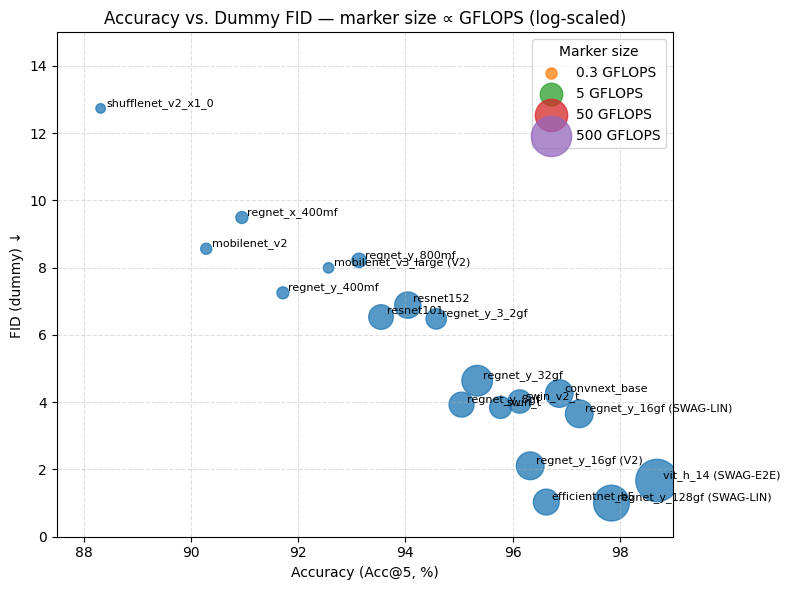

In [4]:
# Re-create the scatter **and** show the data as a matplotlib table (no caas_jupyter_tools).
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Data (Acc@5 and GFLOPS) ---
rows = [
    ("vit_h_14 (SWAG-E2E)",         98.694, 1016.72),
    ("regnet_y_128gf (SWAG-LIN)",   97.844, 127.52),
    ("regnet_y_16gf (SWAG-LIN)",    97.244, 15.91),
    ("convnext_base",               96.870, 15.36),
    ("efficientnet_b5",             96.628, 10.27),
    ("regnet_y_16gf (V2)",          96.328, 15.91),
    ("swin_v2_t",                   96.132, 5.94),
    ("swin_t",                      95.776, 4.49),
    ("regnet_y_32gf",               95.340, 32.28),
    ("regnet_y_8gf",                95.048, 8.47),
    ("regnet_y_3_2gf",              94.576, 3.18),
    ("resnet152",                   94.046, 11.51),
    ("resnet101",                   93.546, 7.80),
    ("regnet_y_800mf",              93.136, 0.83),
    ("mobilenet_v3_large (V2)",     92.566, 0.22),
    ("regnet_y_400mf",              91.716, 0.40),
    ("regnet_x_400mf",              90.950, 0.41),
    ("mobilenet_v2",                90.286, 0.30),
    ("shufflenet_v2_x1_0",          88.316, 0.14),
    ("alexnet",                     79.066, 0.71),
]

df = pd.DataFrame(rows, columns=["model", "acc5", "gflops"])

# --- Dummy FID values ---
rng = np.random.default_rng(42)
base = 100 - df["acc5"].to_numpy()
noise = rng.normal(loc=0.0, scale=1.2, size=len(df))
df["fid_dummy"] = np.clip(base + noise, 1.0, None)

# --- Scatter (marker size ∝ GFLOPS, log-scaled) ---
sizes = (np.log10(df["gflops"].to_numpy() + 1.0) + 0.1) * 300

plt.figure(figsize=(8, 6))
plt.scatter(df["acc5"], df["fid_dummy"], s=sizes, alpha=0.75)

for _, row in df.iterrows():
    plt.annotate(row["model"], (row["acc5"], row["fid_dummy"]),
                 xytext=(4, 2), textcoords="offset points", fontsize=8)

plt.xlabel("Accuracy (Acc@5, %)")
plt.ylabel("FID (dummy) ↓")
plt.ylim([0.0, 15.0])
plt.xlim([87.5, 99.0])
plt.title("Accuracy vs. Dummy FID — marker size ∝ GFLOPS (log-scaled)")
plt.grid(True, linestyle="--", alpha=0.4)

# Size legend
for g in [0.3, 5, 50, 500]:
    plt.scatter([], [], s=(np.log10(g + 1.0) + 0.1) * 300, label=f"{g} GFLOPS", alpha=0.75)
plt.legend(title="Marker size", frameon=True, loc="upper right")

plt.tight_layout()
plt.show()